In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Import Coelho et al. Nature Genetics 2024


In [2]:
be = pd.read_excel("41588_2024_1948_MOESM4_ESM.xlsx", sheet_name="ST2 BE z-scores")
be

,Gene,CRISPR.PAM.Sequence,guide,Location,chr,start_end,start,end,Gene_ID,G_guide,...,cluster,energy_distance,diffusion_score,PFS_outcome_score,amplicon_seq_edit,consequence_amp_seq,HT29_inferred_ploidy,HT29_existing_SNVs,mean_vaf,experimentally_validated_gRNA
0,AKT1,GCGGGGAGAGGGCGGGCCGGCGG,GCGGGGAGAGGGCGGGCCGG,14:104795747-104795769,14.0,104795747-104795769,104795747.0,104795769.0,ENSG00000142208,GCGGGGAGAGGGCGGGCCGG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,AKT1,CGGGGAGAGGGCGGGCCGGCGGC,CGGGGAGAGGGCGGGCCGGC,14:104795746-104795768,14.0,104795746-104795768,104795746.0,104795768.0,ENSG00000142208,GGGGGAGAGGGCGGGCCGGC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,AKT1,GGGAGAGGGCGGGCCGGCGGCGG,GGGAGAGGGCGGGCCGGCGG,14:104795744-104795766,14.0,104795744-104795766,104795744.0,104795766.0,ENSG00000142208,GGGAGAGGGCGGGCCGGCGG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,AKT1,GGAGAGGGCGGGCCGGCGGCGGC,GGAGAGGGCGGGCCGGCGGC,14:104795743-104795765,14.0,104795743-104795765,104795743.0,104795765.0,ENSG00000142208,GGAGAGGGCGGGCCGGCGGC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,AKT1,AGAGGGCGGGCCGGCGGCGGCGG,AGAGGGCGGGCCGGCGGCGG,14:104795741-104795763,14.0,104795741-104795763,104795741.0,104795763.0,ENSG00000142208,GGAGGGCGGGCCGGCGGCGG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45123,NaN,NaN,NTGCGAGCCCAACAGTAAGT,NaN,NaN,NaN,NaN,NaN,NaN,GTGCGAGCCCAACAGTAAGT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45124,NaN,NaN,NATCGGCAGGTTACCTCTGA,NaN,NaN,NaN,NaN,NaN,NaN,GATCGGCAGGTTACCTCTGA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45125,NaN,NaN,NTGCATCAACAAGTACGCGT,NaN,NaN,NaN,NaN,NaN,NaN,GTGCATCAACAAGTACGCGT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45126,NaN,NaN,NTACAGCTAAGTTAAACTCG,NaN,NaN,NaN,NaN,NaN,NaN,GTACAGCTAAGTTAAACTCG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
be[["Gene", "editor"]].dropna().value_counts().head(22)

Gene    editor
BRAF    CBE       3588
        ABE       3588
EGFR    ABE       3515
        CBE       3515
BCL2    ABE       2781
        CBE       2781
PARP1   CBE       2104
        ABE       2104
PIK3CA  CBE       2101
        ABE       2101
AKT1    ABE       2018
        CBE       2018
KRAS    CBE       1503
        ABE       1503
MYC     CBE       1249
        ABE       1249
MAP2K1  ABE       1146
        CBE       1146
MAP2K2  ABE       1122
        CBE       1122
PARP2   CBE        809
        ABE        809
dtype: int64

# Fold-changes


In [4]:
[c for c in be if "average_zscore" in c]

['L2FC_HT29_DebCet_plasmid_average_zscore',
 'L2FC_HT29_Tram_plasmid_average_zscore',
 'L2FC_HT29_Pict_plasmid_average_zscore',
 'L2FC_HT29_Control_plasmid_average_zscore',
 'L2FC_H23_Adag_plasmid_average_zscore',
 'L2FC_H23_Sotor_plasmid_average_zscore',
 'L2FC_H23_Control_plasmid_average_zscore',
 'L2FC_PC9_Control_plasmid_average_zscore',
 'L2FC_PC9_Osim_plasmid_average_zscore',
 'L2FC_PC9_Gefit_plasmid_average_zscore',
 'L2FC_MHHES1_Olap_plasmid_average_zscore',
 'L2FC_MHHES1_Nirap_plasmid_average_zscore',
 'L2FC_MHHES1_Control_plasmid_average_zscore']

In [4]:
be_fc = be[[c for c in be if "average_zscore" in c]]
be_fc

,L2FC_HT29_DebCet_plasmid_average_zscore,L2FC_HT29_Tram_plasmid_average_zscore,L2FC_HT29_Pict_plasmid_average_zscore,L2FC_HT29_Control_plasmid_average_zscore,L2FC_H23_Adag_plasmid_average_zscore,L2FC_H23_Sotor_plasmid_average_zscore,L2FC_H23_Control_plasmid_average_zscore,L2FC_PC9_Control_plasmid_average_zscore,L2FC_PC9_Osim_plasmid_average_zscore,L2FC_PC9_Gefit_plasmid_average_zscore,L2FC_MHHES1_Olap_plasmid_average_zscore,L2FC_MHHES1_Nirap_plasmid_average_zscore,L2FC_MHHES1_Control_plasmid_average_zscore
0,0.652160,0.549812,0.782818,0.457164,0.392406,0.469512,-1.309462,0.611128,0.601516,0.407595,0.214779,0.809421,0.962870
1,0.279646,0.771742,0.584414,0.988497,0.564427,0.480984,0.060075,0.458593,0.550087,0.514836,0.534127,0.321090,0.421233
2,-0.150311,0.376877,0.286674,0.340795,-0.364241,0.194267,-0.266872,0.567145,0.292319,0.405633,0.442586,0.421443,0.051780
3,-0.000013,0.385057,0.697559,0.840249,0.180481,0.015737,-0.301667,0.756255,0.736346,0.701300,0.848250,1.716058,1.562053
4,1.249661,0.755411,0.895976,0.538656,0.738944,0.468905,0.096217,0.843999,0.852167,0.623592,0.857685,1.003862,0.725214
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45123,1.192694,0.799866,1.258901,0.861201,0.739731,1.157495,0.888217,1.630597,0.858344,2.492181,NaN,NaN,NaN
45124,-0.032617,0.209827,0.702865,0.216187,0.025651,0.159697,-0.022722,0.800662,0.201103,1.672302,NaN,NaN,NaN
45125,-0.204948,0.036987,-0.072998,-0.287419,0.418112,-0.163722,0.550288,0.820253,0.333301,1.669195,NaN,NaN,NaN
45126,0.088746,0.093401,-0.112821,0.224725,-0.119645,-0.089589,0.345083,0.401006,-0.115425,1.386051,NaN,NaN,NaN


In [5]:
be_fc = be_fc.dropna(how="any", axis=1)
be_fc

,L2FC_HT29_DebCet_plasmid_average_zscore,L2FC_HT29_Tram_plasmid_average_zscore,L2FC_HT29_Pict_plasmid_average_zscore,L2FC_HT29_Control_plasmid_average_zscore,L2FC_H23_Adag_plasmid_average_zscore,L2FC_H23_Sotor_plasmid_average_zscore,L2FC_H23_Control_plasmid_average_zscore,L2FC_PC9_Control_plasmid_average_zscore,L2FC_PC9_Osim_plasmid_average_zscore,L2FC_PC9_Gefit_plasmid_average_zscore
0,0.652160,0.549812,0.782818,0.457164,0.392406,0.469512,-1.309462,0.611128,0.601516,0.407595
1,0.279646,0.771742,0.584414,0.988497,0.564427,0.480984,0.060075,0.458593,0.550087,0.514836
2,-0.150311,0.376877,0.286674,0.340795,-0.364241,0.194267,-0.266872,0.567145,0.292319,0.405633
3,-0.000013,0.385057,0.697559,0.840249,0.180481,0.015737,-0.301667,0.756255,0.736346,0.701300
4,1.249661,0.755411,0.895976,0.538656,0.738944,0.468905,0.096217,0.843999,0.852167,0.623592
...,...,...,...,...,...,...,...,...,...,...
45123,1.192694,0.799866,1.258901,0.861201,0.739731,1.157495,0.888217,1.630597,0.858344,2.492181
45124,-0.032617,0.209827,0.702865,0.216187,0.025651,0.159697,-0.022722,0.800662,0.201103,1.672302
45125,-0.204948,0.036987,-0.072998,-0.287419,0.418112,-0.163722,0.550288,0.820253,0.333301,1.669195
45126,0.088746,0.093401,-0.112821,0.224725,-0.119645,-0.089589,0.345083,0.401006,-0.115425,1.386051


Text(0.5, 1.0, 'Boxplot of BE z-scores')

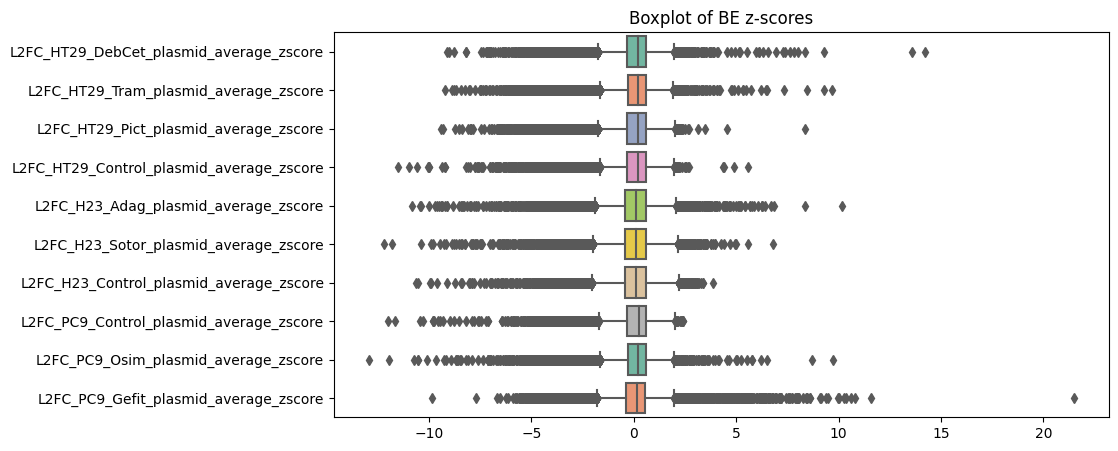

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=be_fc, orient="h", palette="Set2")
plt.title("Boxplot of BE z-scores")

Text(0.5, 1.0, 'Histogram of BE z-scores standard deviation')

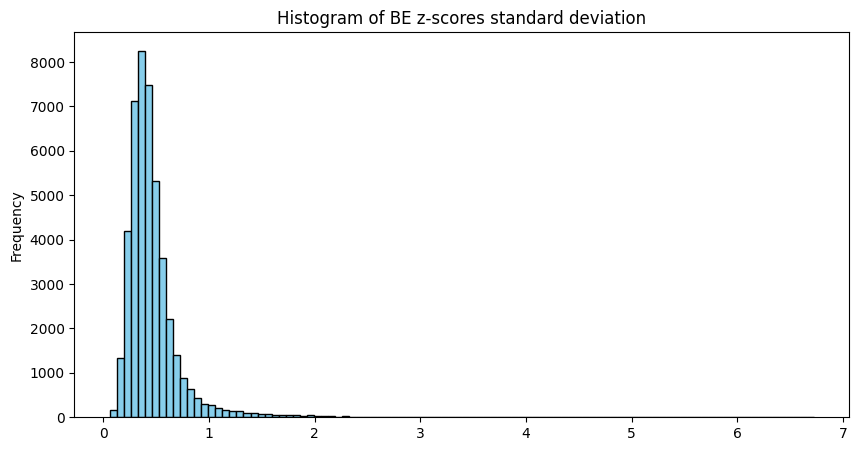

In [7]:
# histogram of be_fc.std()
plt.figure(figsize=(10, 5))

be_fc.std(1).plot(kind="hist", bins=100, color="skyblue", edgecolor="black")

plt.title("Histogram of BE z-scores standard deviation")

In [8]:
be_fc.std(1).median()

0.4065642114816443

In [9]:
n_components = 5

pca = PCA(n_components=n_components)
be_fc_pca = pca.fit_transform(be_fc.T)

be_fc_pca = pd.DataFrame(
    be_fc_pca, columns=[f"PC{i+1}" for i in range(n_components)], index=be_fc.columns
)

In [10]:
be_fc_pca

,PC1,PC2,PC3,PC4,PC5
L2FC_HT29_DebCet_plasmid_average_zscore,-25.601414,-58.615478,-6.453752,12.580480,5.685734
L2FC_HT29_Tram_plasmid_average_zscore,-31.121073,-39.335779,-7.395460,-9.546863,0.187206
L2FC_HT29_Pict_plasmid_average_zscore,-25.729295,-67.363902,2.721187,12.062870,-2.555599
L2FC_HT29_Control_plasmid_average_zscore,-21.285042,-60.660928,7.601774,5.413476,-2.398312
L2FC_H23_Adag_plasmid_average_zscore,88.382158,17.164562,-46.050531,-7.229522,72.584968
L2FC_H23_Sotor_plasmid_average_zscore,92.022663,19.342052,-51.572096,11.186321,-68.377041
L2FC_H23_Control_plasmid_average_zscore,93.412615,16.911749,94.723263,8.822854,-0.429052
L2FC_PC9_Control_plasmid_average_zscore,-43.152396,40.270819,7.814672,-53.384717,-6.670819
L2FC_PC9_Osim_plasmid_average_zscore,-48.901676,49.227563,1.125371,-51.494239,-6.257026
L2FC_PC9_Gefit_plasmid_average_zscore,-78.026540,83.059342,-2.514427,71.589340,8.229941


In [11]:
plot_df = be_fc_pca.reset_index()
plot_df["label"] = [" ".join(c.split("_")[1:3]) for c in plot_df["index"]]
plot_df

,index,PC1,PC2,PC3,PC4,PC5,label
0,L2FC_HT29_DebCet_plasmid_average_zscore,-25.601414,-58.615478,-6.453752,12.580480,5.685734,HT29 DebCet
1,L2FC_HT29_Tram_plasmid_average_zscore,-31.121073,-39.335779,-7.395460,-9.546863,0.187206,HT29 Tram
2,L2FC_HT29_Pict_plasmid_average_zscore,-25.729295,-67.363902,2.721187,12.062870,-2.555599,HT29 Pict
3,L2FC_HT29_Control_plasmid_average_zscore,-21.285042,-60.660928,7.601774,5.413476,-2.398312,HT29 Control
4,L2FC_H23_Adag_plasmid_average_zscore,88.382158,17.164562,-46.050531,-7.229522,72.584968,H23 Adag
5,L2FC_H23_Sotor_plasmid_average_zscore,92.022663,19.342052,-51.572096,11.186321,-68.377041,H23 Sotor
6,L2FC_H23_Control_plasmid_average_zscore,93.412615,16.911749,94.723263,8.822854,-0.429052,H23 Control
7,L2FC_PC9_Control_plasmid_average_zscore,-43.152396,40.270819,7.814672,-53.384717,-6.670819,PC9 Control
8,L2FC_PC9_Osim_plasmid_average_zscore,-48.901676,49.227563,1.125371,-51.494239,-6.257026,PC9 Osim
9,L2FC_PC9_Gefit_plasmid_average_zscore,-78.026540,83.059342,-2.514427,71.589340,8.229941,PC9 Gefit


In [12]:
colors = sns.color_palette("tab20c", n_colors=12).as_hex()
colors = colors[:4] + colors[5:8] + colors[8:11]

palette = {c: colors[i] for i, c in enumerate(plot_df["index"])}

label_map = plot_df.reset_index().groupby("label")["index"].first().to_dict()
palette_label = {c: palette[label_map[c]] for c in plot_df["label"].unique()}
palette_label

{'HT29 DebCet': '#3182bd',
 'HT29 Tram': '#6baed6',
 'HT29 Pict': '#9ecae1',
 'HT29 Control': '#c6dbef',
 'H23 Adag': '#fd8d3c',
 'H23 Sotor': '#fdae6b',
 'H23 Control': '#fdd0a2',
 'PC9 Control': '#31a354',
 'PC9 Osim': '#74c476',
 'PC9 Gefit': '#a1d99b'}

Text(0, 0.5, 'PC2 (21.24%)')

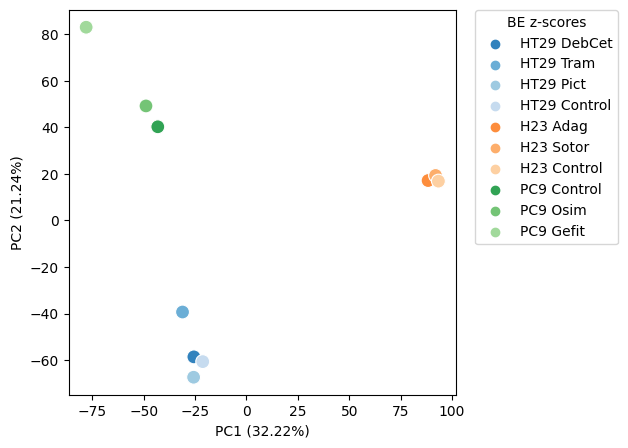

In [13]:
x_var, y_var = 0, 1

plt.figure(figsize=(5, 5))

sns.scatterplot(
    x=f"PC{x_var+1}",
    y=f"PC{y_var+1}",
    data=plot_df,
    hue="label",
    s=100,
    palette=palette_label,
)

# legend outside the plot no box
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0, title="BE z-scores")

plt.xlabel(f"PC{x_var+1} ({pca.explained_variance_ratio_[x_var]*100:.2f}%)")
plt.ylabel(f"PC{y_var+1} ({pca.explained_variance_ratio_[y_var]*100:.2f}%)")

Text(0, 0.5, 'Explained variance ratio')

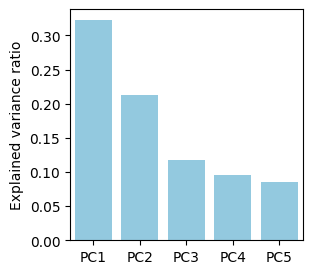

In [14]:
# scree plot
plt.figure(figsize=(3, 3))

sns.barplot(
    x=[f"PC{i+1}" for i in range(n_components)],
    y=pca.explained_variance_ratio_,
    color="skyblue",
)

plt.ylabel("Explained variance ratio")

Text(0.5, 1.0, 'Correlation clustermap of BE z-scores')

<Figure size 500x500 with 0 Axes>

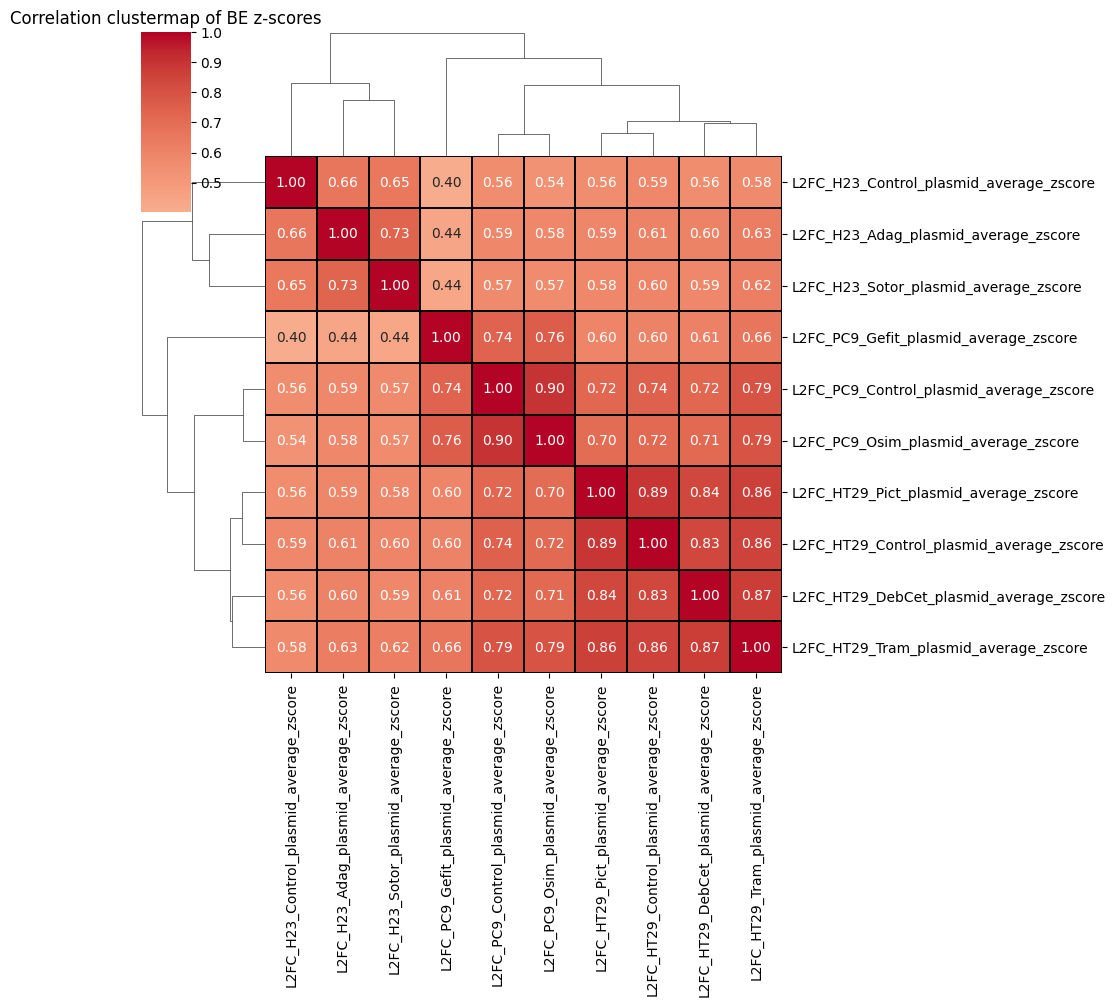

In [15]:
plt.figure(figsize=(5, 5))

sns.clustermap(
    be_fc.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.1,
    linecolor="black",
    annot=True,
    fmt=".2f",
    cbar_pos=(0.02, 0.8, 0.05, 0.18),
    cbar_kws={"orientation": "vertical"},
)

plt.title("Correlation clustermap of BE z-scores")

### PCA by mutations


In [16]:
n_components = 5

pca = PCA(n_components=n_components)
be_fc_pca_ = pca.fit_transform(be_fc)

be_fc_pca_ = pd.DataFrame(
    be_fc_pca_, columns=[f"PC{i+1}" for i in range(n_components)], index=be_fc.T.columns
)
be_fc_pca_

,PC1,PC2,PC3,PC4,PC5
0,-1.185572,0.894841,-0.345792,1.383097,-0.312487
1,-1.630618,0.160463,-0.162169,0.328521,-0.020410
2,-0.515094,0.654184,0.101032,0.106016,-0.118919
3,-1.267148,0.857721,0.075942,0.218200,-0.202486
4,-2.220514,0.348080,-0.186853,0.400781,-0.161026
...,...,...,...,...,...
45123,-3.663542,0.648221,0.911796,0.033755,0.972177
45124,-1.180188,0.957562,0.714046,0.072006,0.742587
45125,-0.852063,0.553756,1.466647,-0.366405,0.570206
45126,-0.574935,0.613764,0.671296,-0.340252,0.859335


Text(0, 0.5, 'Explained variance ratio')

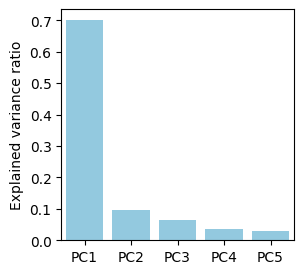

In [17]:
plt.figure(figsize=(3, 3))

sns.barplot(
    x=[f"PC{i+1}" for i in range(n_components)],
    y=pca.explained_variance_ratio_,
    color="skyblue",
)

plt.ylabel("Explained variance ratio")

In [20]:
plot_df_ = be_fc_pca_.reset_index()
plot_df_

,index,PC1,PC2,PC3,PC4,PC5
0,0,-1.185572,0.894841,-0.345792,1.383097,-0.312487
1,1,-1.630618,0.160463,-0.162169,0.328521,-0.020410
2,2,-0.515094,0.654184,0.101032,0.106016,-0.118919
3,3,-1.267148,0.857721,0.075942,0.218200,-0.202486
4,4,-2.220514,0.348080,-0.186853,0.400781,-0.161026
...,...,...,...,...,...,...
45123,45123,-3.663542,0.648221,0.911796,0.033755,0.972177
45124,45124,-1.180188,0.957562,0.714046,0.072006,0.742587
45125,45125,-0.852063,0.553756,1.466647,-0.366405,0.570206
45126,45126,-0.574935,0.613764,0.671296,-0.340252,0.859335


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'PC2 (9.57%)')

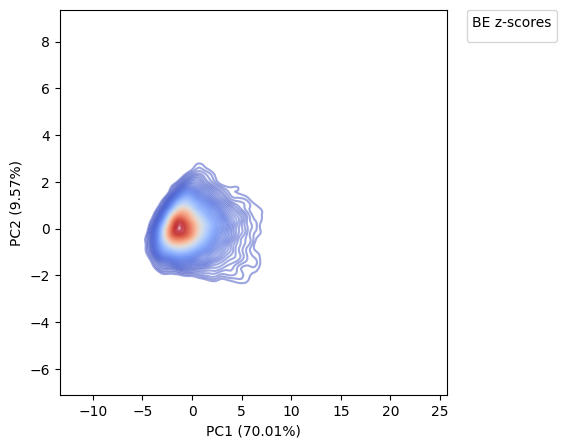

In [26]:
x_var, y_var = 0, 1

plt.figure(figsize=(5, 5))

sns.kdeplot(
    x=f"PC{x_var+1}",
    y=f"PC{y_var+1}",
    data=plot_df_,
    cmap="coolwarm",
    levels=100,
    thresh=0.05,
    alpha=0.5,
)

# legend outside the plot no box
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0, title="BE z-scores")

plt.xlabel(f"PC{x_var+1} ({pca.explained_variance_ratio_[x_var]*100:.2f}%)")
plt.ylabel(f"PC{y_var+1} ({pca.explained_variance_ratio_[y_var]*100:.2f}%)")

# Associations between mutations


In [16]:
# Filter be_fc to keep only the columns with a standard deviation greater than 0.8
corr_matrix = be_fc.loc[be_fc.std(1) > 0.8]
corr_matrix.shape

(3070, 10)

In [17]:
corr_matrix = corr_matrix.loc[(corr_matrix.abs() > 1).sum(1) >= 3]
corr_matrix.shape

(2450, 10)

In [18]:
# Calculate the correlation matrix
corr_matrix = corr_matrix.T.corr(method="spearman")
corr_matrix.shape

(2450, 2450)

In [19]:
# Extract the upper diagonal of the correlation matrix
upper_diag = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
upper_diag.shape

(2450, 2450)

In [20]:
upper_diag = upper_diag.unstack().dropna().sort_values(ascending=False)
upper_diag = upper_diag[upper_diag.abs() > 0.7]
upper_diag.shape

(473033,)

In [21]:
annot_columns = [
    "Gene",
    "allele",
    "Amino_Acid_Position",
    "Protein_Change",
]

upper_diag_annot = pd.concat(
    [
        upper_diag.reset_index(),
        be.loc[[i[0] for i in upper_diag.index]][annot_columns]
        .add_prefix("x_")
        .reset_index(drop=True),
        be.loc[[i[1] for i in upper_diag.index]][annot_columns]
        .add_prefix("y_")
        .reset_index(drop=True),
    ],
    axis=1,
)

In [22]:
upper_diag_annot = upper_diag_annot.dropna(
    subset=["x_Gene", "y_Gene", "x_Protein_Change", "y_Protein_Change"]
)

In [23]:
upper_diag_annot.query("x_Gene != y_Gene").query(
    "x_Protein_Change.str.contains('/') and y_Protein_Change.str.contains('/')"
).head(30)

,level_0,level_1,0,x_Gene,x_allele,x_Amino_Acid_Position,x_Protein_Change,y_Gene,y_allele,y_Amino_Acid_Position,y_Protein_Change
20,10887,4419,1.000000,EGFR,A/G,1,M/V,BCL2,A/G;AGGCCA/GGGCCG,150;148;148;150,F/L;V/A;VAF/AAL
34,27450,15387,1.000000,BRAF,G/A;GCCTGG/ACCTAA,17;16;15;16;17,A/V;Q/*;G;GQA/G*V,MAP2K2,A/G,305,V/A
64,19452,13756,1.000000,PARP2,A/G,9,T/A,MAP2K1,T/C;TT/CC,149;150,G;S/P;GS/GP
70,10066,4419,1.000000,EGFR,T/C,683,L/P,BCL2,A/G;AGGCCA/GGGCCG,150;148;148;150,F/L;V/A;VAF/AAL
77,14496,5019,1.000000,MAP2K1,A/G;AGGCCAA/GGGCCGG,289;290;291;289;291,R/G;P;RPR/GPG,BRAF,T/C;TTCT/CCCC,200;199;199;200,I/V;R;R/G;RI/GV
83,38804,7808,1.000000,MYC,G/A;GACAG/AACAA,216;217;216;217,D/N;S/N;DS/NN,BRAF,A/G;ATTGA/GTTGG,572;571;571;572,I/T;S/P;SI/PT
85,43340,36993,1.000000,PIK3CA,G/A;GG/AA,597;598,Q;A/T;QA/QT,MAP2K1,C/T;CAC/TAT,225;226,G;T/I;GT/GI
91,14353,680,1.000000,MAP2K1,A/G;ACA/GCG,134;135;134;135,Y/C;S/G;YS/CG,AKT1,T/C;TTCTT/CCCCC,386;385;385;386,K/R;K/E;KK/GG
112,14873,13816,0.987879,MAP2K2,T/C;TCT/CCC,205,R;R/G,MAP2K1,T/C;TCT/CCC,85;86;85;86,V/A;S/P;VS/AP
115,21085,14496,0.987879,PIK3CA,T/C;TAGAAT/CAGAAC,22;24;22;24,V/A;C/R;VEC/AER,MAP2K1,A/G;AGGCCAA/GGGCCGG,289;290;291;289;291,R/G;P;RPR/GPG


## Plot specific correlated alteration


In [26]:
idx = 20

In [27]:
plot_df = pd.concat(
    [
        be_fc.iloc[first_indices[0]],
        be_fc.iloc[first_indices[1]],
    ],
    axis=1,
)
plot_df["label"] = [" ".join(c.split("_")[1:3]) for c in plot_df.index]
plot_df

NameError: name 'first_indices' is not defined

In [ ]:
x_data = upper_diag_annot.loc[
    idx, ["x_Gene", "x_Protein_Change", "x_Amino_Acid_Position"]
]
x_data

x_Gene                   EGFR
x_Protein_Change          M/V
x_Amino_Acid_Position       1
Name: 20, dtype: object

In [ ]:
y_data = upper_diag_annot.loc[
    idx, ["y_Gene", "y_Protein_Change", "x_Amino_Acid_Position"]
]
y_data

y_Gene                              BCL2
y_Protein_Change         F/L;V/A;VAF/AAL
x_Amino_Acid_Position                  1
Name: 20, dtype: object

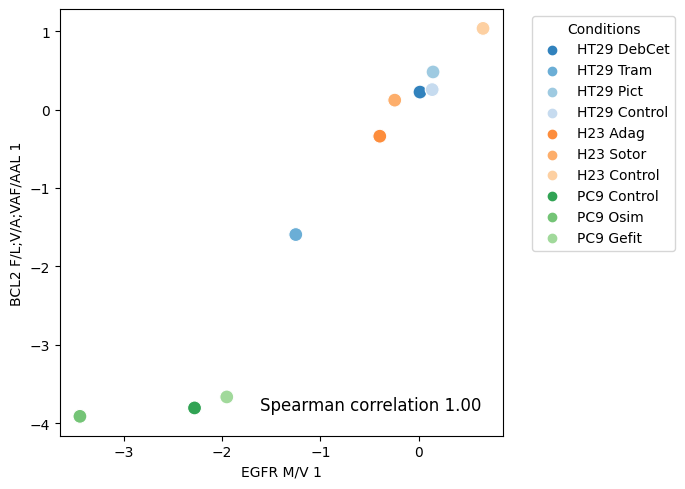

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=plot_df,
    x=plot_df.columns[0],
    y=plot_df.columns[1],
    hue=plot_df["label"],
    palette=palette_label,
    s=100,
)

# annotate with text spearman corr lower right corner
plt.text(
    0.95,
    0.05,
    f"Spearman correlation {upper_diag.iloc[0]:.2f}",
    fontsize=12,
    ha="right",
    va="bottom",
    transform=plt.gca().transAxes,
)

plt.xlabel(
    f"{x_data['x_Gene']} {x_data['x_Protein_Change']} {x_data['x_Amino_Acid_Position']}"
)
plt.ylabel(
    f"{y_data['y_Gene']} {y_data['y_Protein_Change']} {y_data['x_Amino_Acid_Position']}"
)

plt.legend(title="Conditions", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Predictions


In [28]:
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression

In [29]:
metrics = []

## Leave condition out, mutations randomly


In [30]:
# Model: Linear regression
model = LinearRegression()

# Cross-validation: KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Iteration of each condition
for c in be_fc.columns:
    y = be_fc[c]
    x = be_fc.drop(columns=[c])

    y_pred = np.zeros_like(y)

    for train_index, test_index in kf.split(x):
        X_train, X_test = x.iloc[train_index], x.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred[test_index] = model.predict(X_test)

    # Evaluation metric
    metrics.append(
        {
            "validation": "ConditionOutMutationsRandomly",
            "condition": c,
            "r2": r2_score(y, y_pred),
        }
    )

In [31]:
X_train.head()

,L2FC_HT29_DebCet_plasmid_average_zscore,L2FC_HT29_Tram_plasmid_average_zscore,L2FC_HT29_Pict_plasmid_average_zscore,L2FC_HT29_Control_plasmid_average_zscore,L2FC_H23_Adag_plasmid_average_zscore,L2FC_H23_Sotor_plasmid_average_zscore,L2FC_H23_Control_plasmid_average_zscore,L2FC_PC9_Control_plasmid_average_zscore,L2FC_PC9_Osim_plasmid_average_zscore
0,0.652160,0.549812,0.782818,0.457164,0.392406,0.469512,-1.309462,0.611128,0.601516
1,0.279646,0.771742,0.584414,0.988497,0.564427,0.480984,0.060075,0.458593,0.550087
3,-0.000013,0.385057,0.697559,0.840249,0.180481,0.015737,-0.301667,0.756255,0.736346
4,1.249661,0.755411,0.895976,0.538656,0.738944,0.468905,0.096217,0.843999,0.852167
5,0.396634,0.587324,0.771298,0.610960,0.806965,0.395792,-0.363550,0.891952,0.828101


In [32]:
y_train.head()

0    0.407595
1    0.514836
3    0.701300
4    0.623592
5    0.710052
Name: L2FC_PC9_Gefit_plasmid_average_zscore, dtype: float64

## Leave condition out, without cell line


In [104]:
# Model: Linear regression
model = LinearRegression()

# Cross-validation: KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Iteration of each condition
for c in be_fc.columns:
    y = be_fc[c]
    x = be_fc.drop(columns=[i for i in be_fc if i.split("_")[1] == c.split("_")[1]])

    y_pred = np.zeros_like(y)

    for train_index, test_index in kf.split(x):
        X_train, X_test = x.iloc[train_index], x.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred[test_index] = model.predict(X_test)

    # Evaluation metric
    metrics.append(
        {
            "validation": "CellLineOutMutationsRandomly",
            "condition": c,
            "r2": r2_score(y, y_pred),
        }
    )

## Leave condition out, leave gene out


In [105]:
genes_sgrnas = be["Gene"].value_counts()
genes_sgrnas = genes_sgrnas[genes_sgrnas > 10]
genes_sgrnas

BRAF      7176
EGFR      7030
BCL2      5562
PARP1     4208
PIK3CA    4202
AKT1      4036
KRAS      3006
MYC       2498
MAP2K1    2292
MAP2K2    2244
PARP2     1618
Name: Gene, dtype: int64

In [106]:
# Model: Linear regression
model = LinearRegression()

# Iteration of each condition
for c in be_fc.columns:
    y = be_fc[c]
    x = be_fc.drop(columns=[c])

    y_pred = np.zeros_like(y)

    for gene_out in genes_sgrnas.index:
        gene_idx = be[be["Gene"] == gene_out].index
        gene_idx_not = be[be["Gene"] != gene_out].index

        X_train, X_test = x.loc[gene_idx_not], x.loc[gene_idx]
        y_train, y_test = y.loc[gene_idx_not], y.loc[gene_idx]

        model.fit(X_train, y_train)

        y_pred[gene_idx] = model.predict(X_test)

    # Evaluation metric
    metrics.append(
        {
            "validation": "ConditionOutGeneOut",
            "condition": c,
            "r2": r2_score(y, y_pred),
        }
    )

## Leave condition out, without cell line, gene out


In [107]:
# Model: Linear regression
model = LinearRegression()

# Cross-validation: KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Iteration of each condition
for c in be_fc.columns:
    y = be_fc[c]
    x = be_fc.drop(columns=[i for i in be_fc if i.split("_")[1] == c.split("_")[1]])

    y_pred = np.zeros_like(y)

    for gene_out in genes_sgrnas.index:
        gene_idx = be[be["Gene"] == gene_out].index
        gene_idx_not = be[be["Gene"] != gene_out].index

        X_train, X_test = x.loc[gene_idx_not], x.loc[gene_idx]
        y_train, y_test = y.loc[gene_idx_not], y.loc[gene_idx]

        model.fit(X_train, y_train)
        y_pred[gene_idx] = model.predict(X_test)

    # Evaluation metric
    metrics.append(
        {
            "validation": "CellLineOutGeneOut",
            "condition": c,
            "r2": r2_score(y, y_pred),
        }
    )

## Metrics


In [108]:
metrics_df = pd.DataFrame(metrics)
metrics_df["label"] = [" ".join(c.split("_")[1:3]) for c in metrics_df["condition"]]
metrics_df

,validation,condition,r2,label
0,ConditionOutMutationsRandomly,L2FC_HT29_DebCet_plasmid_average_zscore,0.799372,HT29 DebCet
1,ConditionOutMutationsRandomly,L2FC_HT29_Tram_plasmid_average_zscore,0.858585,HT29 Tram
2,ConditionOutMutationsRandomly,L2FC_HT29_Pict_plasmid_average_zscore,0.836372,HT29 Pict
3,ConditionOutMutationsRandomly,L2FC_HT29_Control_plasmid_average_zscore,0.837498,HT29 Control
4,ConditionOutMutationsRandomly,L2FC_H23_Adag_plasmid_average_zscore,0.623716,H23 Adag
5,ConditionOutMutationsRandomly,L2FC_H23_Sotor_plasmid_average_zscore,0.610699,H23 Sotor
6,ConditionOutMutationsRandomly,L2FC_H23_Control_plasmid_average_zscore,0.533012,H23 Control
7,ConditionOutMutationsRandomly,L2FC_PC9_Control_plasmid_average_zscore,0.837973,PC9 Control
8,ConditionOutMutationsRandomly,L2FC_PC9_Osim_plasmid_average_zscore,0.843179,PC9 Osim
9,ConditionOutMutationsRandomly,L2FC_PC9_Gefit_plasmid_average_zscore,0.599894,PC9 Gefit


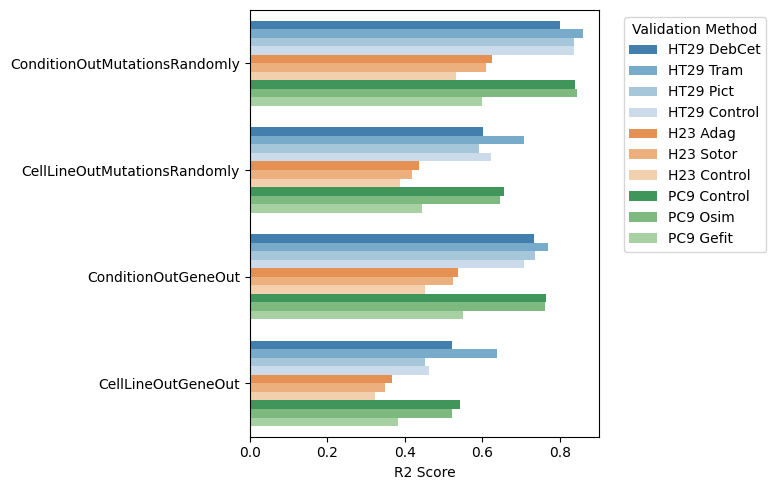

In [116]:
plt.figure(figsize=(8, 5))

sns.barplot(data=metrics_df, x="r2", y="validation", hue="label", palette=palette_label)

plt.xlabel("R2 Score")
plt.ylabel("")

plt.legend(title="Validation Method", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()